In [ ]:
import networkx as nx
import pandas as pd
import numpy as np
from auxiliary_functions import *
from collections import defaultdict

In [19]:
graph = nx.read_gexf("labeled_graph.gexf")
threshold = 0.3

In [20]:
graphs = defaultdict(lambda: nx.Graph())

for a, b, data in graph.edges(data=True):
	graphs[data["subreddit"]].add_edge(a, b, weight=data["weight"])

for subreddit, graph in graphs.items():
	diction = defaultdict(lambda: defaultdict(list))
	for a, b, data in graph.edges(data=True):
		diction[a][b].append(data["weight"])
	new_graph = nx.Graph()
	for node in diction.keys():
		for neighbor in diction[node].keys():
			if node != neighbor:
				if neighbor in diction and node in diction[neighbor]:
					weights = np.array(diction[node][neighbor] + diction[neighbor][node])
				else:
					weights = np.array(diction[node][neighbor])
				if weights.std() < threshold:
					mean = np.mean(weights)
					if mean != 0:
						new_graph.add_edge(node, neighbor, weight=mean)
	graphs[subreddit] = new_graph

null_models = {}
for subreddit, graph in graphs.items():
	null_models[subreddit] = generate_null_model(graph)

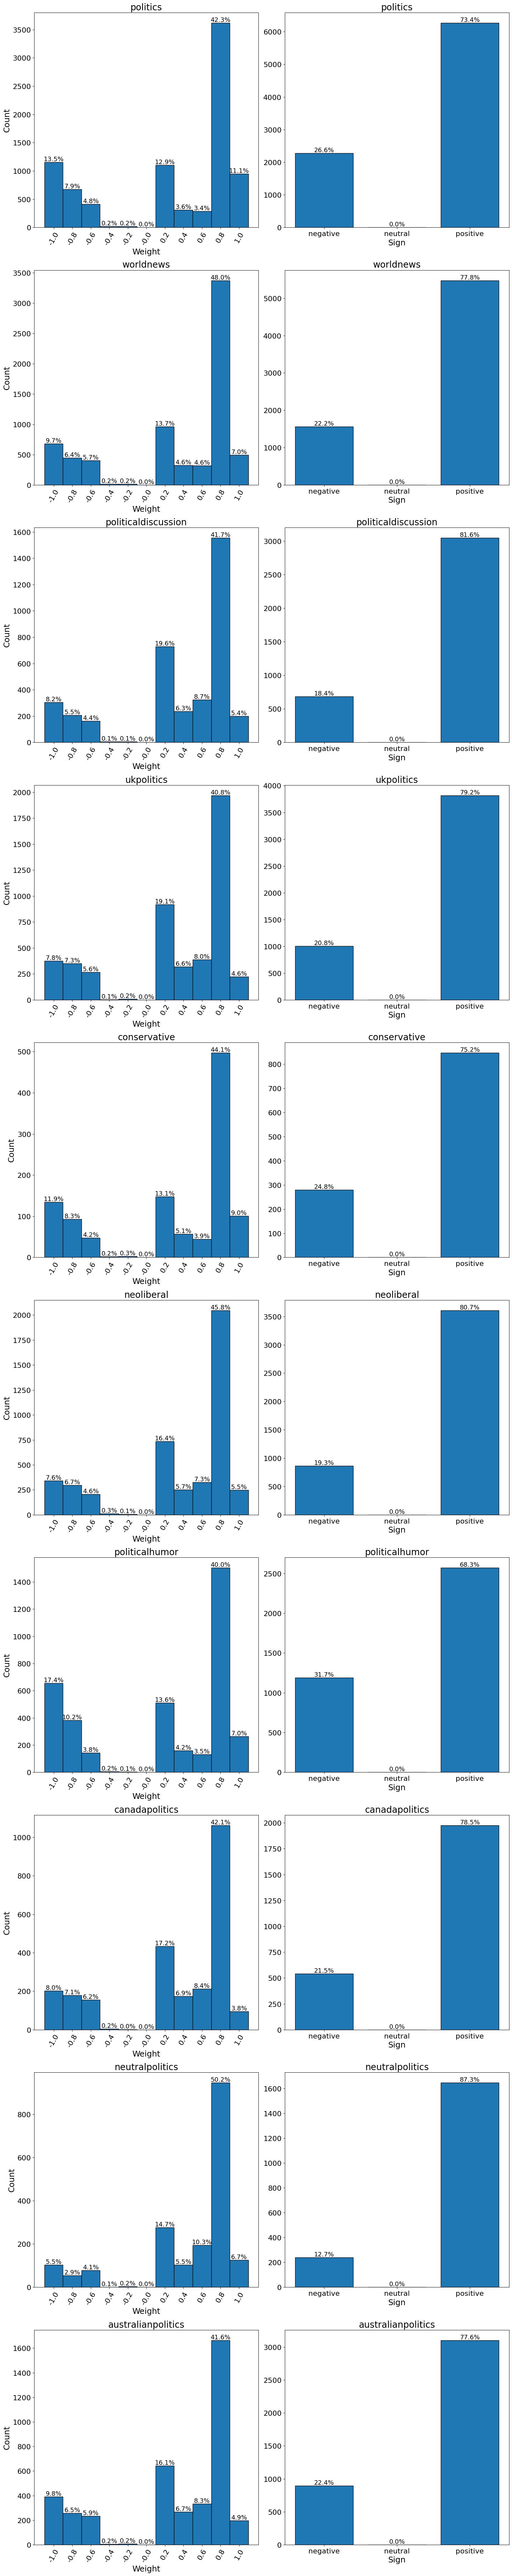

In [21]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(len(graphs), 2, figsize=(16, 8 * len(graphs)))

centers = np.arange(-1, 1.1, 0.2)
edges = centers - .1
edges = np.append(edges, edges[-1] + 0.2)  # add rightmost edge

for ind, subreddit in enumerate(graphs):
    axes[ind][0].set_title(subreddit, fontsize=20)
    axes[ind][1].set_title(subreddit, fontsize=20)
    w = np.array([data["weight"] for a, b, data in graphs[subreddit].edges(data=True)])
    
    # Histogram for weights
    counts, bins, patches = axes[ind][0].hist(w, bins=edges, edgecolor="black")
    axes[ind][0].set_xticks(centers)
    axes[ind][0].set_xticklabels([f"{x:.1f}" for x in centers], rotation=60)
    total = counts.sum()
    for count, bin_left, bin_right in zip(counts, bins[:-1], bins[1:]):
        percent = 100 * count / total if total > 0 else 0
        xpos = (bin_left + bin_right) / 2
        axes[ind][0].text(xpos, count, f"{percent:.1f}%", ha='center', va='bottom', fontsize=14)
    
    # Histogram for sign
    sign_bins = [-1.5, -0.5, 0.5, 1.5]
    sign_labels = ["negative", "neutral", "positive"]
    sign_counts, sign_bins, sign_patches = axes[ind][1].hist(np.sign(w), edgecolor="black", bins=sign_bins, rwidth=0.8)
    axes[ind][1].set_xticks([-1, 0, 1])
    axes[ind][1].set_xticklabels(sign_labels, fontsize=16)
    sign_total = sign_counts.sum()
    for count, bin_left, bin_right in zip(sign_counts, sign_bins[:-1], sign_bins[1:]):
        percent = 100 * count / sign_total if sign_total > 0 else 0
        xpos = (bin_left + bin_right) / 2
        axes[ind][1].text(xpos, count, f"{percent:.1f}%", ha='center', va='bottom', fontsize=14)
    
    axes[ind][0].tick_params(axis='both', labelsize=16)
    axes[ind][1].tick_params(axis='both', labelsize=16)
    axes[ind][0].set_xlabel("Weight", fontsize=18)
    axes[ind][1].set_xlabel("Sign", fontsize=18)
    axes[ind][0].set_ylabel("Count", fontsize=18)



plt.tight_layout()
plt.show()

In [22]:
triangles = {}

for subreddit in graphs.keys():
	triangles[subreddit] = set()
	graph = graphs[subreddit]
	for node1 in graph.nodes:
		for node2 in graph.neighbors(node1):
			for node3 in graph.neighbors(node2):
				if (graph.has_edge(node1, node3)):
					triangles[subreddit].add(tuple(sorted([node1, node2, node3])))
    
triangles


{'politics': {('-AdonaitheBestower-', 'Fillerbear', 'QuantumLettuce2025'),
  ('-AdonaitheBestower-', 'Fillerbear', 'TheNorthC'),
  ('-AdonaitheBestower-', 'Fillerbear', 'WildWeezy'),
  ('-AdonaitheBestower-', 'Fillerbear', 'iyamwhatiyam8000'),
  ('-AdonaitheBestower-', 'ItsSpaghettiLee2112', 'iyamwhatiyam8000'),
  ('-AdonaitheBestower-', 'copyrider', 'iyamwhatiyam8000'),
  ('0-90195', 'minus2cats', 'vard24'),
  ('00Oo0o0OooO0', 'JustTestingAThing', 'omgpuppiesarecute'),
  ('128-NotePolyVA', 'DivinityPen', 'LookOverall'),
  ('141_1337', 'CriticalandPragmatic', 'Remote-Lingonberry71'),
  ('1962NUFan', 'IPromisedNoPosts', 'Outrageous-Hawk4807'),
  ('ALEXC_23', 'Crommach', 'Rikers-Mailbox'),
  ('ALEXC_23', 'EfficientRound321', 'Idyaar'),
  ('ALEXC_23', 'Greedy_Disaster_3130', 'cyphersaint'),
  ('ALEXC_23', 'Idyaar', 'Modronos'),
  ('ALEXC_23', 'Idyaar', 'mrbear120'),
  ('ALEXC_23', 'Idyaar', 'toddywithabody'),
  ('ALEXC_23', 'WhoIsFrancisPuziene', 'mrbear120'),
  ('AZ-FWB', 'Red_Boil_Pus',

In [23]:
no_null = {}

for subreddit in graphs.keys():
	no_null[subreddit] = []
	for node1, node2, node3 in triangles[subreddit]:
		w1 = graphs[subreddit][node1][node2]["weight"]
		w2 = graphs[subreddit][node1][node3]["weight"]
		w3 = graphs[subreddit][node3][node2]["weight"]
		weights = [w1, w2, w3]
		if 0 not in weights:
			no_null[subreddit].append((w1 // abs(w1), w2 // abs(w2), w3 // abs(w3)))

no_null

{'politics': [(np.float64(1.0), np.float64(1.0), np.float64(1.0)),
  (np.float64(1.0), np.float64(-1.0), np.float64(1.0)),
  (np.float64(1.0), np.float64(1.0), np.float64(-1.0)),
  (np.float64(1.0), np.float64(1.0), np.float64(-1.0)),
  (np.float64(1.0), np.float64(1.0), np.float64(1.0)),
  (np.float64(-1.0), np.float64(1.0), np.float64(1.0)),
  (np.float64(1.0), np.float64(-1.0), np.float64(1.0)),
  (np.float64(1.0), np.float64(-1.0), np.float64(1.0)),
  (np.float64(-1.0), np.float64(1.0), np.float64(1.0)),
  (np.float64(1.0), np.float64(-1.0), np.float64(1.0)),
  (np.float64(1.0), np.float64(1.0), np.float64(1.0)),
  (np.float64(1.0), np.float64(1.0), np.float64(-1.0)),
  (np.float64(1.0), np.float64(1.0), np.float64(1.0)),
  (np.float64(-1.0), np.float64(1.0), np.float64(1.0)),
  (np.float64(-1.0), np.float64(1.0), np.float64(-1.0)),
  (np.float64(-1.0), np.float64(1.0), np.float64(1.0)),
  (np.float64(1.0), np.float64(1.0), np.float64(-1.0)),
  (np.float64(1.0), np.float64(1.0), np

In [24]:
series_dict = {}

for subreddit in graphs.keys():
	qnt_pos = [0 for i in range(4)]

	for triangle in no_null[subreddit]:
		qnt_pos[triangle.count(1)] += 1

	qnt_pos_series = pd.Series(qnt_pos, name=subreddit)
	series_dict[subreddit] = qnt_pos_series

# Create DataFrame from the series
df = pd.DataFrame(series_dict).T
df.columns = ['0 pos edges', '1 pos edge', '2 pos edges', '3 pos edges']
df

,0 pos edges,1 pos edge,2 pos edges,3 pos edges
politics,12,37,77,129
worldnews,9,16,52,97
politicaldiscussion,6,45,96,202
ukpolitics,5,37,113,227
conservative,5,15,23,30
neoliberal,11,44,147,311
politicalhumor,12,37,50,65
canadapolitics,1,40,118,247
neutralpolitics,1,11,41,112
australianpolitics,11,124,366,503


In [ ]:
for subreddit, graph in graphs.items():
    simplified_graph = absolute_graph(graph)

SyntaxError: incomplete input (2647007665.py, line 2)